# In i use Kaggel dataset, this data set is net and clean that way i have high accuracy

## 1. Imports

In [41]:
import warnings
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (train_test_split, StratifiedKFold, RandomizedSearchCV, ParameterGrid, cross_val_score)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
warnings.filterwarnings("ignore", category=UserWarning)

In [42]:
RANDOM_STATE = 42
DROP_DUPLICATES = True
N_ITER = 20  

## 2. Load data and explore

In [43]:
df = pd.read_csv('diseases.csv')
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

print("Shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Number of diseases:", df['prognosis'].nunique())

counts = df['prognosis'].value_counts()
print(f"Samples per disease -> min: {counts.min()}, max: {counts.max()}")

Shape: (4920, 133)
Missing values: 0
Duplicate rows: 4616
Number of diseases: 41
Samples per disease -> min: 120, max: 120


In [44]:
if DROP_DUPLICATES:
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Removed {before - len(df)} duplicate rows. New shape: {df.shape}")

counts = df['prognosis'].value_counts()
print(f"Samples per disease after cleaning -> min: {counts.min()}, max: {counts.max()}")

Removed 4616 duplicate rows. New shape: (304, 133)
Samples per disease after cleaning -> min: 5, max: 10


## 3. Define X and y, encode labels, split

In [45]:
x = df.drop('prognosis', axis=1)
y_raw = df['prognosis']

le = LabelEncoder()
y = le.fit_transform(y_raw)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

N_FOLDS = int(max(2, min(5, np.bincount(y_train).min())))
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print("Train:", x_train.shape, "| Test:", x_test.shape, "| CV folds:", N_FOLDS)

Train: (243, 132) | Test: (61, 132) | CV folds: 4


## 4. Models and evaluation helper

In [46]:
def get_models():
    return {
        'Naive Bayes':   GaussianNB(),
        'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'XGBoost':       XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    }

SIMPLICITY = {'Naive Bayes': 0, 'Decision Tree': 1, 'Random Forest': 2, 'XGBoost': 3}

PARAM_DISTRIBUTIONS = {
    'Naive Bayes': {
        'var_smoothing': np.logspace(-11, -5, 7),
    },
    'Decision Tree': {
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5],
        'criterion': ['gini', 'entropy'],
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5],
        'max_features': ['sqrt', 'log2'],
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
    },
}


def evaluate(model, x_train, y_train, x_test, y_test, le, cv):
    y_pred = model.predict(x_test)
    cv_scores = cross_val_score(model, x_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    return {
        'model':    model,
        'accuracy': accuracy_score(y_test, y_pred),
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'cm':       confusion_matrix(y_test, y_pred, labels=np.arange(len(le.classes_))),
        'report':   classification_report(y_test, y_pred,
                        labels=np.arange(len(le.classes_)),
                        target_names=le.classes_,
                        output_dict=True, zero_division=0),
        'y_pred':   y_pred,
    }

## 5. Base models

In [47]:
def base_models(x_train, y_train, x_test, y_test, le, cv):
    results = {}
    for name, model in get_models().items():
        print(f"Training {name}...")
        model.fit(x_train, y_train)
        results[name] = evaluate(model, x_train, y_train, x_test, y_test, le, cv)
    return results


base_results = base_models(x_train, y_train, x_test, y_test, le, cv)

Training Naive Bayes...
Training Decision Tree...
Training Random Forest...
Training XGBoost...


## 6. Hyperparameter tuning (RandomizedSearchCV)

In [48]:
def tune_models(x_train, y_train, x_test, y_test, le, cv):
    results = {}
    for name, model in get_models().items():
        dist = PARAM_DISTRIBUTIONS[name]
        n_iter = min(N_ITER, len(ParameterGrid(dist)))
        print(f"Tuning {name} ({n_iter} candidates x {cv.get_n_splits()} folds)...")

        search = RandomizedSearchCV(
            model, dist, n_iter=n_iter, cv=cv, scoring='accuracy',
            n_jobs=-1, random_state=RANDOM_STATE, refit=True
        )
        search.fit(x_train, y_train)

        res = evaluate(search.best_estimator_, x_train, y_train, x_test, y_test, le, cv)
        res['best_params'] = search.best_params_
        results[name] = res
    return results


tuned_results = tune_models(x_train, y_train, x_test, y_test, le, cv)

Tuning Naive Bayes (7 candidates x 4 folds)...
Tuning Decision Tree (20 candidates x 4 folds)...
Tuning Random Forest (20 candidates x 4 folds)...
Tuning XGBoost (20 candidates x 4 folds)...


## 7. Compare models and pick the best

In [49]:
rows = []
for stage, results in [('Base', base_results), ('Tuned', tuned_results)]:
    for name, m in results.items():
        rows.append({
            'Stage': stage, 'Model': name,
            'Test accuracy': m['accuracy'],
            'CV mean': m['cv_mean'], 'CV std': m['cv_std'],
        })

summary = pd.DataFrame(rows)
display(summary.round(4))

# Pick the best tuned model by CV score (not test score), break ties with the simpler model.
def selection_key(item):
    name, m = item
    return (-round(m['cv_mean'], 3), SIMPLICITY[name], -round(m['accuracy'], 3))

best_model_name, best_metrics = sorted(tuned_results.items(), key=selection_key)[0]
best_model = best_metrics['model']

print(f"\nBest model: {best_model_name}")
print(f"Test accuracy: {best_metrics['accuracy']:.4f} | CV: {best_metrics['cv_mean']:.4f} +/- {best_metrics['cv_std']:.4f}")
print("Best params:", best_metrics['best_params'])

,Stage,Model,Test accuracy,CV mean,CV std
0,Base,Naive Bayes,0.9836,1.0000,0.0000
1,Base,Decision Tree,0.7049,0.7285,0.0124
2,Base,Random Forest,1.0000,1.0000,0.0000
3,Base,XGBoost,0.8852,0.8562,0.0368
4,Tuned,Naive Bayes,0.9836,1.0000,0.0000
5,Tuned,Decision Tree,0.6885,0.7367,0.0154
6,Tuned,Random Forest,1.0000,1.0000,0.0000
7,Tuned,XGBoost,0.9180,0.9013,0.0161



Best model: Naive Bayes
Test accuracy: 0.9836 | CV: 1.0000 +/- 0.0000
Best params: {'var_smoothing': np.float64(1e-11)}


## 8. Detailed results for the best model

In [50]:
report_df = pd.DataFrame(best_metrics['report']).T
display(report_df.round(3))

per_class = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
display(per_class.sort_values('f1-score').head(5).round(3))

,precision,recall,f1-score,support
(vertigo) Paroymsal Positional Vertigo,1.000,1.000,1.000,1.000
AIDS,1.000,1.000,1.000,1.000
Acne,1.000,1.000,1.000,1.000
Alcoholic hepatitis,1.000,1.000,1.000,2.000
Allergy,1.000,1.000,1.000,1.000
Arthritis,1.000,1.000,1.000,1.000
Bronchial Asthma,1.000,1.000,1.000,1.000
Cervical spondylosis,1.000,1.000,1.000,1.000
Chicken pox,1.000,1.000,1.000,2.000
Chronic cholestasis,1.000,0.500,0.667,2.000


,precision,recall,f1-score,support
Chronic cholestasis,1.000,0.5,0.667,2.0
Hepatitis D,0.667,1.0,0.800,2.0
Acne,1.000,1.0,1.000,1.0
(vertigo) Paroymsal Positional Vertigo,1.000,1.0,1.000,1.0
Allergy,1.000,1.0,1.000,1.0


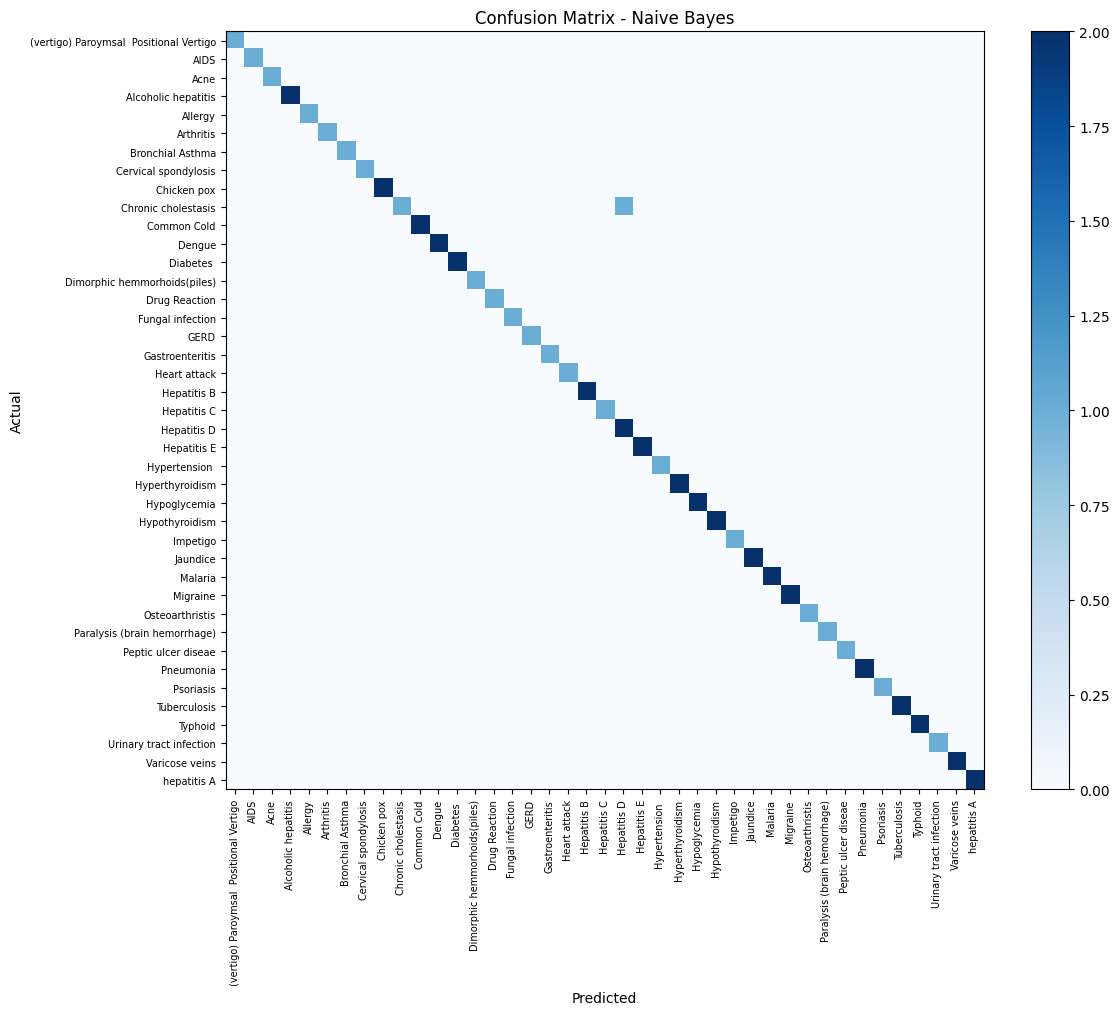

In [51]:
cm = best_metrics['cm']

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap='Blues')
ax.set_title(f'Confusion Matrix - {best_model_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=90, fontsize=7)
ax.set_yticklabels(le.classes_, fontsize=7)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 9. Save the model together with the label encoder and feature names

In [52]:
bundle = {
    'model':         best_model,
    'label_encoder': le,
    'feature_names': list(x.columns),
    'model_name':    best_model_name,
}

model_filename = f"{best_model_name.replace(' ', '_').lower()}_best_model.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(bundle, f)

print(f"Saved '{model_filename}'")

Saved 'naive_bayes_best_model.pkl'


## 10. Predict from a list of symptoms

In [53]:
def predict_disease(symptoms, bundle_path=model_filename, top_k=3):
    """Return the top_k most likely diseases for a list of symptom names."""
    with open(bundle_path, 'rb') as f:
        b = pickle.load(f)

    features = b['feature_names']
    lookup = {f.strip().lower().replace(' ', '_'): f for f in features}

    row = pd.DataFrame(np.zeros((1, len(features))), columns=features)
    unknown = []
    for s in symptoms:
        key = s.strip().lower().replace(' ', '_')
        if key in lookup:
            row.loc[0, lookup[key]] = 1
        else:
            unknown.append(s)

    if unknown:
        print("Unknown symptoms ignored:", unknown)

    proba = b['model'].predict_proba(row)[0]
    top_idx = np.argsort(proba)[::-1][:top_k]
    return [(b['label_encoder'].classes_[i], float(proba[i])) for i in top_idx]


example_symptoms = list(x.columns[:3])
print("Symptoms:", example_symptoms)
for disease, p in predict_disease(example_symptoms):
    print(f"  {disease}: {p:.2%}")

Symptoms: ['itching', 'skin_rash', 'nodal_skin_eruptions']
  Fungal infection: 100.00%
  Varicose veins: 0.00%
  Urinary tract infection: 0.00%
